# 분류

- 예측 대상(Y)이 연속된 숫자가 아니라, 정해진 범주(카테고리) 중 하나다.
- 목표는 "얼마인가"가 아니라 "어디에 속하는가"를 맞추는 것.
- 모델마다 방식은 다르지만, 결국 각 범주에 속할 "확률" 또는 "점수"를 계산하고, 그중 가장 그럴듯한 범주를 최종 답으로 고른다.

In [20]:
# 로지스틱 분류

# 회귀식을 통과시켜 나온 값을 X축으로 둔다.
# 그 결과값을 시그모이드(또는 softmax) 함수로 통과시켜, 각 범주에 속할 확률(0~1)로 압축시킨다.
# 확률이 가장 높은 범주를 최종 예측값으로 선택한다.

# 사용 가능할 때: X축에 대해서 Y축이 단조 증가(또는 감소)일 때 - 만약 U자 형태의 분포라면 성능이 매우 안 좋아짐

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

feature_data = np.array([-4, -3, -2, -1, 1, 2, 3, 4]).reshape(-1, 1)
# 분류 모델은 label 데이터를 1차원 형태로 기대
label_data = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# penalty가 어떤 가중치가 좋은 가중치인지의 기준을 정하는 것이었다면
# solver는 그 기준으로 어떻게 다가갈지를 정하는 파라미터(경사하강법 등의 계산방법) - lbfgs가 default
sci_model = LogisticRegression()
sci_model.fit(feature_data, label_data)

# 예측 (최종 범주, 0.5 기준으로 자동 분류됨)
pred = sci_model.predict(feature_data)
print("예측 범주:", pred)

# Accuracy 직접 계산(분류부터는 평가 지표를 loss보다 Accuracy로 확인)
def accuracy(pred, label_data):
  return np.mean(pred == label_data)

print("Accuracy:", accuracy(pred, label_data))

예측 범주: [0 0 0 0 1 1 1 1]
Accuracy: 1.0


In [ ]:
# 노드: 정보를 담고 있는 하나의 점
# 의사결정나무: 여러 가지 규칙을 순차적으로 적용하면서 독립변수 공간을 분리, 그 중 작게 분할된 공간에 대한 값을 예측하는 분류

# 모델 학습 순서
# 1. 주어진 독립 변수 중 하나의 독립변수를 선택하고 그 독립변수에 대한 기준값(threshold)을 정함. 이를 분류 규칙이라고 함
# 2. 1에서 정해진 분류 규칙을 기준으로 학습 데이터 집합(부모 노드)을 나눔
#    부모 노드에는 분류 규칙에 의해 나뉘기 전의 데이터를, 자식 노드에는 각각 분류 규칙을 통해 나눠진 데이터가 할당됨
# 3. 부모 노드에는 학습용 전체 데이터가 할당된 상태에서 시작하여,
#    각각의 자식 노드에 대해 1~2의 단계를 반복하여 하위의 자식 노드를 만듦
#    단, 자식 노드에 한가지 클래스의 데이터만 존재한다면 더 이상 자식 노드를 나누지 않고 중지하고 해당 클래스로 분류하도록 함

# 분류 규칙 정하는 방법
# 정보 획득량(구분 전/후 각 영역의 순도 증가 및 불순도, 불확실성 감소)이 가장 큰 독립변수와 기준값을 분류 규칙에 이용
# 정보 획득량 이해를 위해 '자기 정보'와 '앤트로피(entropy)' 개념 숙지 필요

# 자기 정보: 확률이 작을수록 장기 정보값이 커진다.(사건이 적게 일어날수록 놀라움이 증가하므로)
# 앤트로피: 0(완전 순수, 한 클래스만 있음) ~ 1(완전 불순, 반반 섞임) 사이 값
#         높을수록 그 집단의 특징을 찾기 힘들어짐 - 범주가 넓어질 시 1을 넘길 수도 있음
# 정보 획득량: 나누기 전 엔트로피 - 나눈 후 엔트로피 = 나눠서 얼마나 더 순수해졌는가
#            이 값이 가장 큰 (feature, 기준값) 조합을 분류 규칙으로 선택
#            예) 전력(feature) > 200W(기준값)를 기준으로 분류할 때 정보 획득량이 높으면 '불순도 높음 - 불순도 낮음'이 되는 것이니까 선정

# 모델 예측
# 학습 때 정해진 분기 처리 질문이 각 분기마다 존재
# 새로운 데이터가 넘어왔을 때 그 질문을 기반으로 맨 아래 노드(leaf node)로 이동시키고,
# 그 leaf node에 모여있던 학습 데이터 중 다수였던 클래스로 예측

# 모델 특징
# Greedy: 각 분기 시점에서 그 순간 가장 좋아 보이는 선택지만 고르고 한 번 정하면 되돌아가지 않는 방식
# 가지치기(Pruning): Full tree(순도 100%까지 다 나눈 트리)는 과적합 위험이 있어서,
#                    특정 지점의 질문(분류 규칙)을 없애고 그 지점을 leaf로 되돌리는 작업
#                    (학습이 어느 정도 끝난 후, 사후적으로 진행됨)
# 비용함수: "트리를 더 단순하게 만들지(가지치기), 그대로 둘지"를 정하는 기준
#          오차(틀리는 정도) + 트리 복잡도(leaf 개수)를 합쳐서 계산 <- 이 값이 작을수록 좋은 트리
#          가지치기했을 때 이 값이 더 작아지면 → 가지치기함
#          alpha가 크면: 복잡도를 더 싫어함 → 가지치기를 많이 함 (단순한 트리)
#          alpha가 작으면: 복잡도를 덜 신경씀 → 가지치기를 적게 함 (복잡한 트리)

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

data = load_iris()
X = data.data      # feature 4개 다 사용 (꽃받침 길이/너비, 꽃잎 길이/너비)
y = data.target    # 정답 (0, 1, 2 세 종류)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

for depth in [1, 2, 3, 4, 5, 6, None]:
  # criterion='entropy': 정보 획득량 기준으로 분류 규칙 적용
  # max_depth: 가지치기의 실무적 구현 (트리가 자랄 수 있는 최대 깊이 제한)
  # 사전 가지치기(max_depth 등)를 사용하면, 이론에서 배운 비용함수 기반 사후 가지치기(ccp_alpha)는 실무에서 따로 챙길 필요가 없다.
  # max_depth 값을 반복문으로 바꿔가며 val accuracy를 직접 확인하는 것만으로 충분하기 때문
  model = DecisionTreeClassifier(criterion='entropy', max_depth=depth)
  model.fit(X_train, y_train)
  train_acc = model.score(X_train, y_train)
  val_acc = model.score(X_val, y_val)
  print(f"max_depth={depth}: train_acc={train_acc:.3f}, val_acc={val_acc:.3f}")

max_depth=1: train_acc=0.692, val_acc=0.567
max_depth=2: train_acc=0.958, val_acc=0.967
max_depth=3: train_acc=0.967, val_acc=0.967
max_depth=4: train_acc=0.992, val_acc=1.000
max_depth=5: train_acc=1.000, val_acc=1.000
max_depth=6: train_acc=1.000, val_acc=1.000
max_depth=None: train_acc=1.000, val_acc=1.000


In [ ]:
# 회귀나무: 분류나무와 구조는 동일, 차이는 딱 두 가지
# 1. leaf node의 예측값 = 다수결 클래스가 아니라, 그 leaf에 모인 y값들의 평균
# 2. 분기 기준 = 엔트로피(정보획득량)가 아니라, 오차제곱합(MSE)이 최소가 되는 곳
# max_depth를 조절하여 정확도 계산, 계단식 예측 한계는 XGBoost에서 해결
from sklearn.tree import DecisionTreeRegressor  # Classifier → Regressor

model = DecisionTreeRegressor(max_depth=3)
model.fit(X, y)  # y는 이제 범주가 아니라 연속값(숫자)
model.score(X, y)  # 여기선 accuracy 대신 R² 점수가 나옴

1.0

In [ ]:
# 분류 모델 평가 기법

# 잡아내고 싶은 것이 Positive(스팸 메일, 암 있음, 설비 고장 등)
# True Positive(TP)  는 실제 데이터가 Positive(긍정)인데 모델도 Positive라고 잘 예측했을 때  → 고장을 고장이라고 제대로 잡아냄
# True Negative(TN)  는 실제 데이터가 Negative(부정)인데 모델도 Negative라고 잘 예측했을 때  → 정상을 정상이라고 제대로 판단함
# False Positive(FP) 는 실제 데이터가 Negative인데 모델은 Positive라고 잘못 예측했을 때    → 정상인데 고장이라고 오판 (괜히 점검, 손해는 적음)
# False Negative(FN) 는 실제 데이터가 Positive인데 모델은 Negative라고 잘못 예측했을 때    → 고장인데 정상이라고 놓침 (제일 위험한 실수)

# 정확도(Accuracy): 전체 중 맞춘 비율 — 클래스 불균형 땐 믿을 수 없음
# 정밀도(Precision): 모델이 Positive라 한 것 중 진짜 Positive 비율 — 모델 입장의 정확도 (𝑃𝑟𝑒𝑐𝑖𝑠𝑖𝑜𝑛=TP/(TP+FP))
# 재현율(Recall): 실제 Positive 중 모델이 잡아낸 비율 — 데이터(정답) 입장의 정확도 (𝑅𝑒𝑐𝑎𝑙𝑙=TP/(TP+FN))
# F1 score: 정밀도와 재현율을 혼합한 지표로 조화평균(한쪽 지표가 좋지 않을 때 전체 점수를 확실히 나쁘게 만들어야 하므로)을 사용
#          한쪽 지표가 매우 안 좋으면(예: Precision 낮음) F1도 낮게 나와서 모델의 약점을 숨기지 않고 정직하게 보여준다
# ROC 커브: "임계값을 바꿔가면서, Recall과 Fall-out(오탐율)이 어떻게 같이 변하는지"를 한 그래프로 보여주는 것
# AUC: ROC 커브 그래프를 숫자 하나(1에 가까울수록 좋음)로 요약한 것
# 다만, 예지보전처럼 클래스가 심하게 불균형한 경우엔 이 지표가 실제보다 좋아 보이는 착시를 줄 수 있으니
# Recall/Precision/F1을 우선으로 보고 ROC/AUC는 보조 참고용으로 쓰기

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.model_selection import GridSearchCV

def select_model():
    
    estimator = DecisionTreeClassifier(random_state=81)
    
    # estimator의 튜닝을 위한 파라미터를 지시사항에 따라 지정
    param_grid = {'max_depth': [2, 3, 4, 5]}
    
    # 최적 파라미터로 다시 estimator를 학습시킬지 말지를 지정
    # 학습 후에 최적 파라미터를 찾았으므로 그 파라미터 가지고 전체 데이터를 학습
    refit = True
    
    # k-fold 교차 검증(데이터를 나눌 때 여러 번 다르게 나눠서 평균을 냄)
    k = 5
    
    # 성능 평가 방법(예지 보전처럼 고장을 정말로 놓치지 않아야 하면 recall 등을 사용)
    scoring = 'f1_micro'

    # k-fold * max_depth만큼 학습
    selected_model = GridSearchCV(estimator = estimator, 
                                  param_grid = param_grid,
                                  refit = refit, 
                                  cv = k,
                                  scoring = scoring)
    
    return selected_model


def train_model(model, feature, label):
    
    trained_model = model.fit(feature, label)
    
    # 학습된 모델들 중 최적의 모델을 찾아내기
    best_model = trained_model.best_estimator_

    return best_model


def var_importance(best_model):
    
    # 학습된 모델들 중 최적의 모델에 사용된 독립변수의 중요도
    return best_model.feature_importances_

c:\Users\ABHCST9\Desktop\dev\workspace\next_ai\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\ABHCST9\Desktop\dev\workspace\next_ai\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[[3.3 0. ]
 [3.4 0. ]
 [3.5 0. ]
 ...
 [8.6 7.8]
 [8.7 7.8]
 [8.8 7.8]]
[[3.3 0. ]
 [3.4 0. ]
 [3.5 0. ]
 ...
 [8.6 7.8]
 [8.7 7.8]
 [8.8 7.8]]
[[3.3 0. ]
 [3.4 0. ]
 [3.5 0. ]
 ...
 [8.6 7.8]
 [8.7 7.8]
 [8.8 7.8]]
[[3.3 0. ]
 [3.4 0. ]
 [3.5 0. ]
 ...
 [8.6 7.8]
 [8.7 7.8]
 [8.8 7.8]]


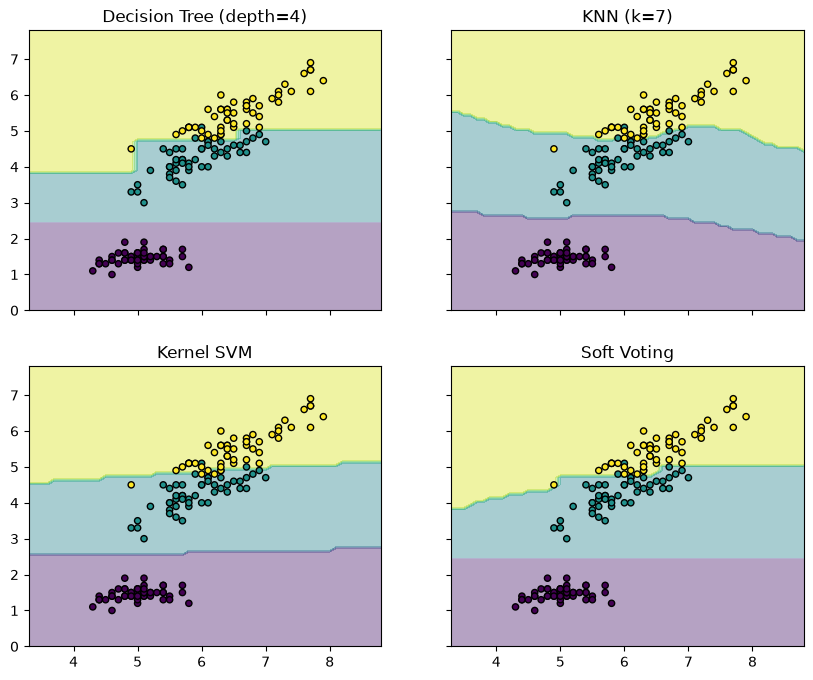

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

iris = datasets.load_iris()
X = iris.data[:, [0, 2]] # 시각화 위해 두 컬럼만
y = iris.target
# soft voting을 위한 모델 초기화
clf1 = DecisionTreeClassifier(max_depth=4)
clf2 = KNeighborsClassifier(n_neighbors=7)
clf3 = SVC(gamma=.1, kernel='rbf', probability=True)

# 따로 만들어진 모델을 하나의 투표하는 모델로 만들기
eclf = VotingClassifier(
  estimators=[('dt', clf1), ('knn', clf2), ('svc', clf3)], # 모델 넣기
  voting='soft', # 투표 방식
  weights=[2, 1, 2] # 각 모델의 신뢰 정도를 정하기(높을수록 더 신뢰한다는 뜻)
)

clf1.fit(X, y)
clf2.fit(X, y)
clf3.fit(X, y)
eclf.fit(X, y) # 내부적으로 세 개의 모델을 다 학습

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1 # 특성1의 범위
y_min, y_mzx = X[:, 1].min() - 1, X[:, 1].max() + 1 # 특성2의 범위
# 조합에 필요한 재료(x표, y표)"를 만들어주는 것까지고, 그 재료를 실제 좌표 쌍으로 조립하는 마지막 작업(ravel + c_)은 우리가 따로 해줘야 함
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_mzx, 0.1))

# 2 * 2의 그래프 생성
# figsize: 10, 8인치로 고정(화면이 작아보일 때 설정하면 됨)
# sharex, y: X, Y축을 공유하고 각 영역의 최대 최소 만큼 다른 영역도 확대되어 표기된다.
f, axarr = plt.subplots(2, 2, sharex='col', sharey='row', figsize=(10, 8))

for idx, clf, tt in zip(
  ([0, 0], [0, 1], [1, 0], [1, 1]),
  [clf1, clf2, clf3, eclf],
  ['Decision Tree (depth=4)', 'KNN (k=7)', 'Kernel SVM', 'Soft Voting']
):
  print(np.c_[xx.ravel(), yy.ravel()])
  Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.4)
  axarr[idx[0], idx[1]].scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
  axarr[idx[0], idx[1]].set_title(tt)


In [ ]:
# 결론: 회귀든 분류든, 모델의 목표는 결국 하나다.
#      진짜 패턴(신호 - 예: 회귀의 실제 곡선, 분류의 U자 같은 비단조 관계)은 정확히 잡아내고,
#      우연한 노이즈에는 흔들리지 않게 만드는 것 (= 과적합 방지)